In [73]:
import collections
import os
import json

import functorch.dim
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import rasterio
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchinfo
import torchvision
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix
from torch.optim.lr_scheduler import StepLR
from torch.utils.data import Dataset, DataLoader, random_split
from torchinfo import summary
from torchvision import datasets, transforms
from tqdm import tqdm
from sklearn.metrics import f1_score
from collections import Counter

In [74]:
print("torch version : ", torch.__version__)
print("torchvision version : ", torchvision.__version__)
print("torchinfo version : ", torchinfo.__version__)
print("numpy version : ", np.__version__)
print("matplotlib version : ", matplotlib.__version__)
print("rasterio version : ", rasterio.__version__)



torch version :  2.12.0
torchvision version :  0.27.0
torchinfo version :  1.8.0
numpy version :  2.4.6
matplotlib version :  3.10.9
rasterio version :  1.5.0


In [75]:
if torch.cuda.is_available():
    device = "cuda"
elif torch.backends.mps.is_available():
    device = "mps"
else:
    device = "cpu"

print(f"Using {device} device.")

Using mps device.


Since we are working with dataset that is made of 13 channeled tif files (in comparison with default RGB images) we have to create our own dataset class because pytroch's ImageFolder takes only images as inputs.A custom Dataset class must implement three functions: __init__, __len__, and __getitem__. Lets implement them:

In [76]:
class EuroSATdataset(Dataset):
    def __init__(self, csv_file, root_dir,label_map_path, transform=None):
        self.data = pd.read_csv(csv_file)
        self.root = root_dir
        self.transform = transform

        with open(label_map_path) as f:
            label_map = json.load(f)
        self.class_to_idx = label_map
        self.classes = [None] * len(label_map)
        for name, idx in label_map.items():
            self.classes[idx] = name
    def __len__(self):
        return len(self.data)
    def __getitem__(self, idx):
        row = self.data.iloc[idx]
        path = os.path.join(self.root,row["Filename"])
        with rasterio.open(path) as src:
            img = torch.from_numpy(src.read()).float()
        if self.transform:
            img = self.transform(img)
        label = int(row["Label"])
        return img, label


In [77]:
Train_dataset = EuroSATdataset("EuroSATallBands/train.csv","EuroSATallBands","EuroSATallBands/label_map.json")


In [78]:
check = Train_dataset.__getitem__(1)[0]
print(f"Shape of one data we have:{check.shape}")
print(f"Classes we have:{Train_dataset.classes}")

Shape of one data we have:torch.Size([13, 64, 64])
Classes we have:['AnnualCrop', 'Forest', 'HerbaceousVegetation', 'Highway', 'Industrial', 'Pasture', 'PermanentCrop', 'Residential', 'River', 'SeaLake']


In [79]:
train_loader = DataLoader(Train_dataset,batch_size=32,shuffle=True)
first_batch = next(iter(train_loader))
print(f"Shape of one batch:{first_batch[0].shape}")


Shape of one batch:torch.Size([32, 13, 64, 64])


In [80]:
def get_mean_std(loader):
    channels_sum, channels_squared_sum, num_batches = 0,0,0
    for data,_ in tqdm(loader,desc="computing mean and standard deviation",leave=False):
        channels_sum+=torch.mean(data,dim =[0,2,3])
        channels_squared_sum+=torch.mean(data ** 2,dim =[0,2,3])
        num_batches+=1
    mean = channels_sum/num_batches
    std =(channels_squared_sum/num_batches-mean**2)**0.5
    return mean,std


In [81]:
mean,std = get_mean_std(train_loader)
print(f"Mean: {mean}")
print(f"Standard deviation: {std}")

Mean: tensor([1353.9431, 1115.3807, 1033.2864,  934.7151, 1180.4196, 1964.8369,
        2326.7625, 2254.4763,  723.2306,   13.1454, 1780.2852, 1097.9352,
        2543.0701])
Standard deviation: tensor([ 243.2799,  330.1420,  395.1947,  592.9124,  574.9126,  885.2305,
        1113.6151, 1142.7401,  404.9038,    9.1860, 1026.2584,  764.8419,
        1267.5636])


In [82]:
norm_transform = transforms.Normalize(mean,std)

In [83]:
norm_train_dataset = EuroSATdataset("EuroSATallBands/train.csv","EuroSATallBands","EuroSATallBands/label_map.json",transform=norm_transform)
norm_train_loader = DataLoader(norm_train_dataset,batch_size=32,shuffle=True)
print(get_mean_std(norm_train_loader))

(tensor([ 6.9230e-05,  8.4674e-05,  3.7755e-05,  1.9961e-05, -6.5425e-05,
        -1.2707e-04, -1.3209e-04, -1.3212e-04, -1.7247e-04, -3.2515e-05,
        -1.2425e-04, -1.0278e-04, -1.3374e-04]), tensor([1.0001, 1.0001, 1.0000, 1.0000, 1.0000, 1.0001, 1.0000, 1.0000, 1.0000,
        1.0000, 1.0001, 1.0000, 1.0000]))


In [101]:
norm_val_dataset = EuroSATdataset("EuroSATallBands/validation.csv","EuroSATallBands","EuroSATallBands/label_map.json",transform=norm_transform)
val_loader = DataLoader(norm_val_dataset,batch_size=32,shuffle=False)

In [85]:
length_val = len(norm_val_dataset)
length_train = len(norm_train_dataset)
length_dataset = length_val+length_train
percent_train = np.round(100 * length_train / length_dataset, 2)
percent_val = np.round(100 * length_val / length_dataset, 2)
print(f"Train data is {percent_train}% of full data")
print(f"Validation data is {percent_val}% of full data")

Train data is 77.78% of full data
Validation data is 22.22% of full data


In [86]:
def class_counts(dataset):
    c = collections.Counter(x[1] for x in tqdm(dataset))
    class_to_index = dataset.class_to_idx
    return pd.Series({cat: c[idx] for cat, idx in class_to_index.items()})


In [87]:
train_class_distribution= class_counts(norm_train_dataset)

100%|██████████| 19317/19317 [00:38<00:00, 505.64it/s]


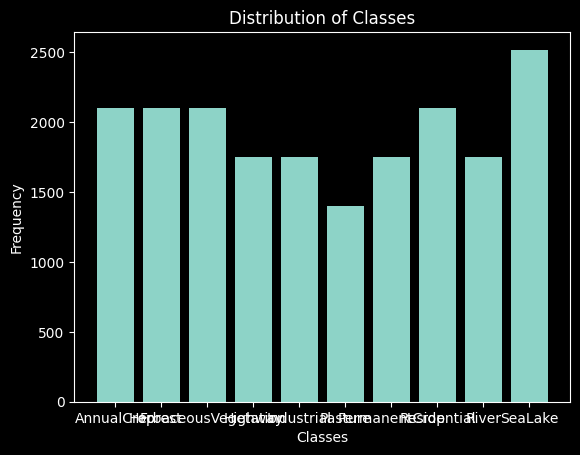

In [88]:
categories = norm_train_dataset.classes
values = train_class_distribution
plt.bar(categories,values)
plt.xlabel("Classes")
plt.ylabel("Frequency")
plt.title("Distribution of Classes")
plt.show()

It seems our biggest class (SeaLake, 2517) is only about 1.8× our smallest (Pasture, 1400) and it is not worth to undersample the data as imbalance is not that dramatic./

100%|██████████| 5519/5519 [00:10<00:00, 502.59it/s]


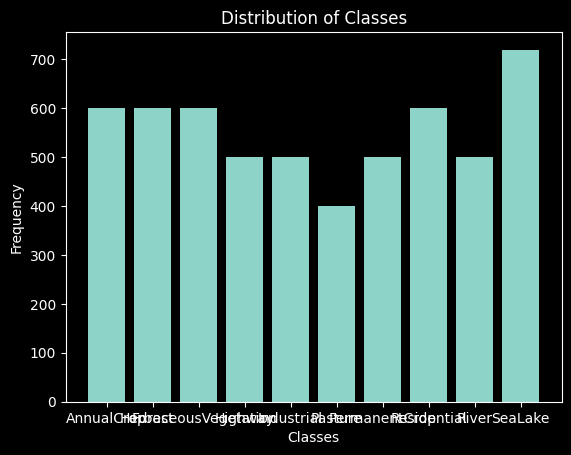

In [89]:
val_class_distribution = class_counts(norm_val_dataset)
plt.bar(categories,val_class_distribution)
plt.xlabel("Classes")
plt.ylabel("Frequency")
plt.title("Distribution of Classes")
plt.show()

Validation dataset also looks good!

In [90]:
model = torch.nn.Sequential()
model.append(nn.Conv2d(in_channels=13,out_channels=64,kernel_size=3,padding=1,bias=False))
model.append(nn.BatchNorm2d(num_features=64))
model.append(nn.ReLU())
model.append(nn.MaxPool2d(kernel_size=2,stride=2))
model.append(nn.Conv2d(in_channels=64,out_channels=128,kernel_size=3,padding=1,bias=False))
model.append(nn.BatchNorm2d(num_features=128))
model.append(nn.BatchNorm2d(num_features=128))
model.append(nn.ReLU())
model.append(nn.MaxPool2d(kernel_size=2,stride=2))
model.append(nn.Conv2d(in_channels=128,out_channels=256,kernel_size=3,padding=1,bias=False))
model.append(nn.BatchNorm2d(num_features=256))
model.append(nn.ReLU())
model.append(nn.MaxPool2d(kernel_size=2,stride=2))
model.append(nn.Conv2d(in_channels=256,out_channels=512,kernel_size=3,padding=1,bias=False))
model.append(nn.BatchNorm2d(num_features=512))
model.append(nn.ReLU())
model.append(nn.MaxPool2d(kernel_size=2,stride=2))
model.append(nn.Flatten())
model.append(nn.Dropout(p=0.5))
model.append(nn.Linear(in_features=8192,out_features=10))



Sequential(
  (0): Conv2d(13, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
  (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (2): ReLU()
  (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (4): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
  (5): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (6): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (7): ReLU()
  (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (9): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
  (10): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (11): ReLU()
  (12): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (13): Conv2d(256, 512, kernel_size=(3, 3),

In [91]:
summary(model,input_size=(32,13,64,64))

Layer (type:depth-idx)                   Output Shape              Param #
Sequential                               [32, 10]                  --
├─Conv2d: 1-1                            [32, 64, 64, 64]          7,488
├─BatchNorm2d: 1-2                       [32, 64, 64, 64]          128
├─ReLU: 1-3                              [32, 64, 64, 64]          --
├─MaxPool2d: 1-4                         [32, 64, 32, 32]          --
├─Conv2d: 1-5                            [32, 128, 32, 32]         73,728
├─BatchNorm2d: 1-6                       [32, 128, 32, 32]         256
├─BatchNorm2d: 1-7                       [32, 128, 32, 32]         256
├─ReLU: 1-8                              [32, 128, 32, 32]         --
├─MaxPool2d: 1-9                         [32, 128, 16, 16]         --
├─Conv2d: 1-10                           [32, 256, 16, 16]         294,912
├─BatchNorm2d: 1-11                      [32, 256, 16, 16]         512
├─ReLU: 1-12                             [32, 256, 16, 16]         --

In [92]:
loss_fn = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(),lr=0.001)

Lets create train,predict and score functions

In [93]:
def train_epoch(model,optimizer,loss_fn,data_loader,device):
    training_loss = 0.0
    model.train()
    for inputs,targets in tqdm(data_loader,desc="training",leave=False):
        optimizer.zero_grad()
        inputs = inputs.to(device)
        targets = targets.to(device)
        outputs = model(inputs)
        loss = loss_fn(outputs,targets)
        loss.backward()
        optimizer.step()
        training_loss += loss.data.item()*inputs.size(0)
    return training_loss/len(data_loader.dataset)

In [94]:
def predict(model,data_loader,device):
    all_probs=torch.tensor([]).to(device)
    model.eval()
    with torch.no_grad():
        for inputs,targets in tqdm(data_loader,desc="predicting",leave=False):
            inputs = inputs.to(device)
            output=model(inputs)
            probs=F.softmax(output,dim=1)
            all_probs = torch.cat((all_probs,probs),dim=0)
    return all_probs


In [125]:
def score(model, data_loader, loss_fn, device):
    total_loss = 0
    total_correct = 0
    all_preds = []
    all_targets = []

    model.eval()
    with torch.no_grad():
        for inputs, targets in tqdm(data_loader, desc="Scoring", leave=False):
            inputs  = inputs.to(device)
            targets = targets.to(device)
            output  = model(inputs)

            loss = loss_fn(output, targets)
            total_loss += loss.item() * inputs.size(0)

            preds = torch.argmax(output, dim=1)
            correct = torch.eq(preds, targets)
            total_correct += torch.sum(correct).item()

            # Collect for F1 (move to CPU to avoid building a big GPU tensor)
            all_preds.append(preds.cpu())
            all_targets.append(targets.cpu())

    n_observations = len(data_loader.dataset)         # ← bug fix, see below
    average_loss   = total_loss / n_observations
    accuracy       = total_correct / n_observations

    all_preds   = torch.cat(all_preds).numpy()
    all_targets = torch.cat(all_targets).numpy()
    macro_f1    = f1_score(all_targets, all_preds, average="macro")

    return average_loss, accuracy, macro_f1

In [123]:
model=model.to(device)

 lets add learning rate scheduler. We will be training our model for 60 epochs so i think step size 20 and gamma factor 0.1 works in our case

In [96]:
step_size = 20
gamma = 0.1
scheduler = StepLR(optimizer, step_size=step_size, gamma=gamma)

In [114]:
def early_stopping(validation_f1, best_val_f1, counter, patience=5):

    stop = False

    if validation_f1 > best_val_f1:                    # F1: higher = better
        counter = 0
    else:
        counter += 1

    if counter >= patience:
        stop = True

    return counter, stop

In [115]:
def checkpointing(validation_f1, best_val_f1, model, optimizer, save_path):
    if validation_f1 > best_val_f1:
        torch.save(
            {
                "model_state_dict": model.state_dict(),
                "optimizer_state_dict": optimizer.state_dict(),
                "f1": validation_f1,
            },
            save_path,
        )
        print(f"Checkpoint saved with validation F1 {validation_f1:.4f}")

In [118]:
def train(
    model,
    optimizer,
    loss_fn,
    train_loader,
    val_loader,
    epochs,
    device,
    scheduler=None,
    checkpoint_path=None,
    early_stopping_fn=None,         # renamed to avoid collision with the function
):
    # Track model progress over epochs
    train_losses = []
    train_accuracies = []
    train_f1s = []
    val_losses = []
    val_accuracies = []
    val_f1s = []
    learning_rates = []

    # Track best F1 for checkpointing + early stopping
    best_val_f1 = 0.0               # F1 starts low, we want it to climb
    early_stopping_counter = 0

    print("Model evaluation before start of training...")
    train_loss, train_accuracy, train_f1 = score(model, train_loader, loss_fn, device)
    train_losses.append(train_loss)
    train_accuracies.append(train_accuracy)
    train_f1s.append(train_f1)

    validation_loss, validation_accuracy, validation_f1 = score(model, val_loader, loss_fn, device)
    val_losses.append(validation_loss)
    val_accuracies.append(validation_accuracy)
    val_f1s.append(validation_f1)

    for epoch in range(1, epochs + 1):
        print("\n")
        print(f"Starting epoch {epoch}/{epochs}")

        # Train one epoch
        train_epoch(model, optimizer, loss_fn, train_loader, device)

        # Evaluate on training set (eval mode)
        train_loss, train_accuracy, train_f1 = score(model, train_loader, loss_fn, device)
        train_losses.append(train_loss)
        train_accuracies.append(train_accuracy)
        train_f1s.append(train_f1)

        # Evaluate on validation set
        validation_loss, validation_accuracy, validation_f1 = score(model, val_loader, loss_fn, device)
        val_losses.append(validation_loss)
        val_accuracies.append(validation_accuracy)
        val_f1s.append(validation_f1)

        print(f"Epoch: {epoch}")
        print(f"Training   — loss: {train_loss:.4f}, acc: {train_accuracy*100:.2f}%, F1: {train_f1:.4f}")
        print(f"Validation — loss: {validation_loss:.4f}, acc: {validation_accuracy*100:.2f}%, F1: {validation_f1:.4f}")

        # Log LR (use the one applied this epoch), then step scheduler
        lr = optimizer.param_groups[0]["lr"]
        learning_rates.append(lr)
        if scheduler:
            scheduler.step()

        # Checkpoint if val F1 improved
        if checkpoint_path:
            checkpointing(
                validation_f1, best_val_f1, model, optimizer, checkpoint_path
            )

        # Early stopping
        if early_stopping_fn:
            early_stopping_counter, stop = early_stopping_fn(
                validation_f1, best_val_f1, early_stopping_counter
            )
            if stop:
                print(f"Early stopping triggered after {epoch} epochs")
                break

        # Update best AFTER checkpointing/early-stopping (they need the old best to compare)
        if validation_f1 > best_val_f1:
            best_val_f1 = validation_f1

    return (
        learning_rates,
        train_losses,
        val_losses,
        train_accuracies,
        val_accuracies,
        train_f1s,
        val_f1s,
        epoch
    )

In [126]:
epochs = 60
train_results = train(model,optimizer,loss_fn,train_loader,val_loader,epochs=epochs,device=device, scheduler=scheduler, checkpoint_path="checkpoint model/model.pth",early_stopping_fn=early_stopping)



Model evaluation before start of training...




Starting epoch 1/60


KeyboardInterrupt: 